# Importy

In [3]:
import os
import json
import random
import re
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Device

In [4]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


# Dataset - poziom słów

In [2]:
class CVLWordsDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        return img, label

# Split danych

In [7]:
WORD_PATTERN = re.compile(r"^(\d+)-(\d+)-(\d+)-(\d+)-.*$")

In [8]:
def split_words_using_saved_pages(
    words_root_dir,
    authors_json,
    pages_split_path="split_pages_lines_27.json"
):
    with open(authors_json, "r") as f:
        author_to_label = json.load(f)

    with open(pages_split_path, "r") as f:
        pages_info = json.load(f)

    train_samples, val_samples = [], []

    for author, info in tqdm(pages_info.items(), desc="Przetwarzanie autorów (WORDS)"):
        label = info["label"]
        train_pages = set(info["train_pages"])
        val_pages   = set(info["val_pages"])

        author_dir = os.path.join(words_root_dir, author)
        if not os.path.isdir(author_dir):
            continue

        for fname in os.listdir(author_dir):
            if not fname.lower().endswith((".tif", ".tiff", ".png", ".jpg")):
                continue

            m = WORD_PATTERN.match(fname)
            if m is None:
                continue

            page_id = m.group(2)
            full_path = os.path.join(author_dir, fname)

            if page_id in train_pages:
                train_samples.append((full_path, label))
            elif page_id in val_pages:
                val_samples.append((full_path, label))

    print(f"Train WORDS: {len(train_samples)} | Val WORDS: {len(val_samples)}")
    return train_samples, val_samples


In [9]:
def print_split_overview(train_samples, val_samples):
    train_labels = [l for _, l in train_samples]
    val_labels   = [l for _, l in val_samples]

    print("\nTRAIN:")
    for k, v in sorted(Counter(train_labels).items()):
        print(f"  Klasa {k}: {v}")

    print("\nVAL:")
    for k, v in sorted(Counter(val_labels).items()):
        print(f"  Klasa {k}: {v}")


# Transformacje

In [10]:
def get_transforms():
    train_t = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224,224)),
        transforms.RandomRotation(5),
        transforms.ColorJitter(0.2,0.2),
        transforms.RandomAffine(0, translate=(0.05,0.05), scale=(0.95,1.05)),
        transforms.GaussianBlur(3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    val_t = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    return train_t, val_t


# Model ResNet-50

In [11]:
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

# Trening i ewaluacja

In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


In [13]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return total_loss / total, correct / total, all_labels, all_preds

# Główna funkcja treningowa

In [14]:
def train_model(
    train_samples,
    val_samples,
    stages,
    batch_size=32,
    save_path="best_model_words.pth"
):
    transform_train, transform_val = get_transforms()

    train_dataset = CVLWordsDataset(train_samples, transform_train)
    val_dataset   = CVLWordsDataset(val_samples, transform_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    num_classes = len(set(l for _, l in train_samples))
    model = build_model(num_classes)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    for stage in stages:
        print(f"\nStage: {stage['name']} | epochs={stage['epochs']} | lr={stage['lr']}")

        for p in model.parameters():
            p.requires_grad = False

        if "all" in stage["unfreeze"]:
            for p in model.parameters():
                p.requires_grad = True
        else:
            for name, module in model.named_children():
                if name in stage["unfreeze"]:
                    for p in module.parameters():
                        p.requires_grad = True

        for p in model.fc.parameters():
            p.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=stage["lr"]
        )

        for epoch in range(stage["epochs"]):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
            va_loss, va_acc, labels, preds = evaluate(model, val_loader, criterion)

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)

            print(f"Epoch {epoch+1}/{stage['epochs']} | "
                  f"Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f}")

            if va_acc > best_val_acc:
                best_val_acc = va_acc
                torch.save(model.state_dict(), save_path)
                print(f"✔ Saved best model (val_acc={va_acc:.4f})")

    print(f"\nBEST VAL ACC: {best_val_acc:.4f}")
    return model, labels, preds, history


# Wykresy

In [15]:
def plot_history(history, title_suffix="WORDS"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss over epochs ({title_suffix})")
    plt.legend()
    plt.grid(True)

    # ACCURACY
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy over epochs ({title_suffix})")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [16]:
def plot_confusion(labels, preds, title="Confusion Matrix (WORDS)"):
    classes = sorted(list(set(labels)))
    cm = confusion_matrix(labels, preds)

    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(10,10))
    disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=True)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


In [17]:
def author_difficulty(labels, preds):
    cm = confusion_matrix(labels, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    sorted_idx = np.argsort(per_class_acc)

    print("\nNajtrudniejsi autorzy:")
    for i in sorted_idx[:5]:
        print(f"Autor {i} – Acc: {per_class_acc[i]:.4f}")

    print("\nNajłatwiejsi autorzy:")
    for i in sorted_idx[-5:]:
        print(f"Autor {i} – Acc: {per_class_acc[i]:.4f}")

    return per_class_acc


# Uruchomienie 

Przetwarzanie autorów (WORDS): 100%|██████████| 27/27 [00:00<00:00, 493.94it/s]


Train WORDS: 8547 | Val WORDS: 3600

TRAIN:
  Klasa 0: 313
  Klasa 1: 312
  Klasa 2: 288
  Klasa 3: 312
  Klasa 4: 327
  Klasa 5: 330
  Klasa 6: 325
  Klasa 7: 288
  Klasa 8: 325
  Klasa 9: 330
  Klasa 10: 310
  Klasa 11: 325
  Klasa 12: 335
  Klasa 13: 304
  Klasa 14: 325
  Klasa 15: 312
  Klasa 16: 325
  Klasa 17: 296
  Klasa 18: 353
  Klasa 19: 328
  Klasa 20: 288
  Klasa 21: 313
  Klasa 22: 330
  Klasa 23: 285
  Klasa 24: 333
  Klasa 25: 327
  Klasa 26: 308

VAL:
  Klasa 0: 137
  Klasa 1: 137
  Klasa 2: 163
  Klasa 3: 140
  Klasa 4: 123
  Klasa 5: 120
  Klasa 6: 125
  Klasa 7: 160
  Klasa 8: 124
  Klasa 9: 120
  Klasa 10: 140
  Klasa 11: 125
  Klasa 12: 112
  Klasa 13: 147
  Klasa 14: 125
  Klasa 15: 138
  Klasa 16: 125
  Klasa 17: 155
  Klasa 18: 100
  Klasa 19: 121
  Klasa 20: 161
  Klasa 21: 137
  Klasa 22: 121
  Klasa 23: 161
  Klasa 24: 117
  Klasa 25: 123
  Klasa 26: 143

Stage: Layer4 | epochs=10 | lr=0.0001
Epoch 1/10 | Train Acc: 0.3621 | Val Acc: 0.6619
✔ Saved best model

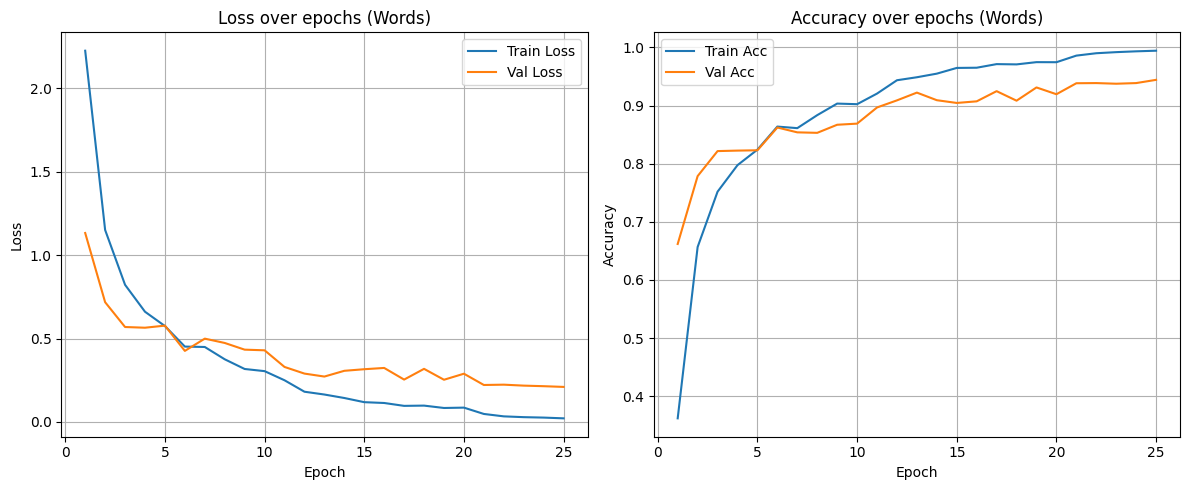

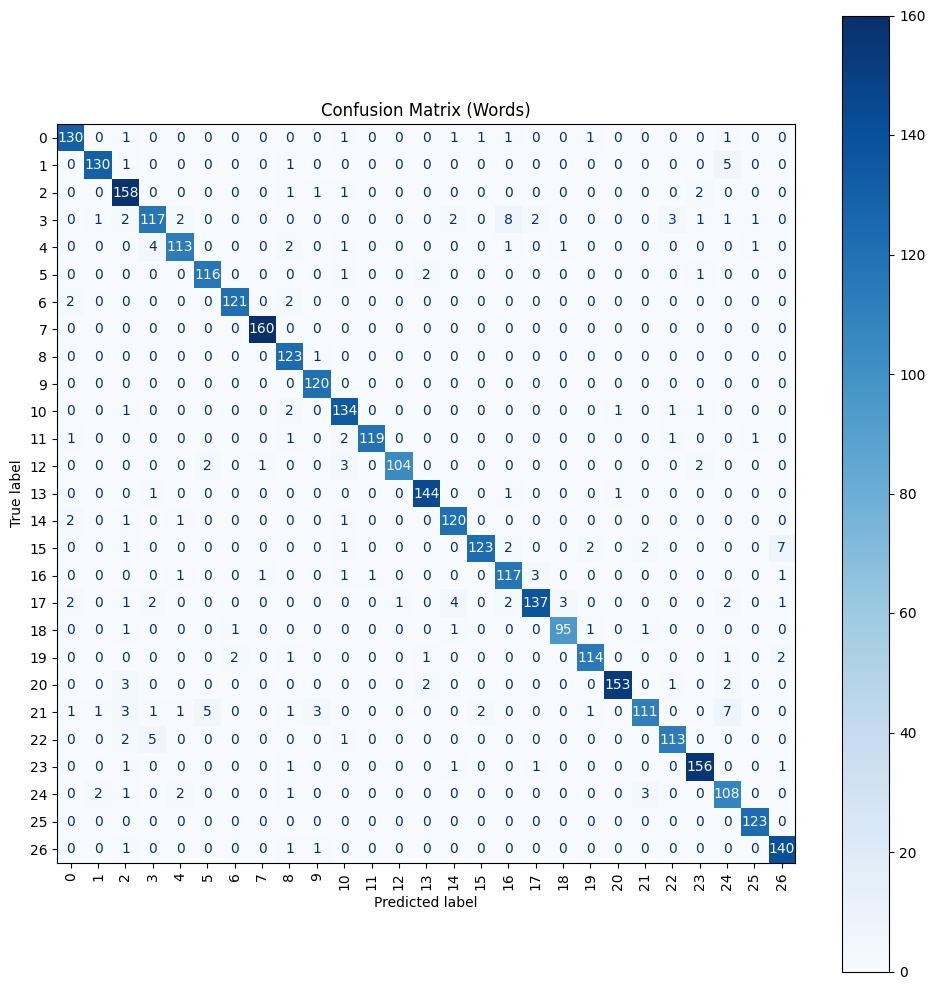


Najtrudniejsi autorzy:
Autor 21 – Acc: 0.8102
Autor 3 – Acc: 0.8357
Autor 17 – Acc: 0.8839
Autor 15 – Acc: 0.8913
Autor 4 – Acc: 0.9187

Najłatwiejsi autorzy:
Autor 13 – Acc: 0.9796
Autor 8 – Acc: 0.9919
Autor 9 – Acc: 1.0000
Autor 7 – Acc: 1.0000
Autor 25 – Acc: 1.0000


In [18]:
WORDS_ROOT = "/Users/maciekgrubek/Downloads/cvl-database-1-1/trainset/words"
AUTHORS_JSON = "/Users/maciekgrubek/PracaInzynierska/authors.json"

train_samples, val_samples = split_words_using_saved_pages(
    WORDS_ROOT,
    AUTHORS_JSON,
    pages_split_path="split_pages_lines_27.json"
)

print_split_overview(train_samples, val_samples)

stages = [
    {"name": "Layer4", "unfreeze": ["layer4"], "epochs": 10, "lr": 1e-4},
    {"name": "Layer3+4", "unfreeze": ["layer3","layer4"], "epochs": 10, "lr": 5e-5},
    {"name": "Full FT", "unfreeze": ["all"], "epochs": 5, "lr": 1e-5},
]

model, labels, preds, history = train_model(
    train_samples,
    val_samples,
    stages,
    batch_size=32,
    save_path="best_model_words.pth"
)

plot_history(history, title_suffix="Words")
plot_confusion(labels, preds, title="Confusion Matrix (Words)")
per_class_acc_words = author_difficulty(labels, preds)